# 03: Accessibility Metrics

**Goal**: Calculate accessibility indices to identify transit deserts - neighborhoods with poor transit access to jobs.

**What We'll Do**:
1. Load travel time matrix from Notebook 02
2. Calculate jobs reachable within 15/30/45/60 minutes for each origin
3. Calculate per-capita accessibility (jobs per 1,000 residents)
4. Merge results back to tracts
5. Create visualizations to identify transit deserts

**Outputs**:
- `outputs/accessibility_metrics.parquet` - Accessibility scores by tract
- `outputs/accessibility_metrics.geojson` - For mapping
- Visualizations: maps, charts, transit desert identification



In [10]:
from pathlib import Path
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins

ROOT = Path("/Users/aaryakhanna/transit-deserts").resolve()
os.chdir(ROOT)

data_raw = ROOT / "data_raw"
outputs = ROOT / "outputs"

print("✓ Imports loaded")
print(f"Working directory: {ROOT}")


✓ Imports loaded
Working directory: /Users/aaryakhanna/transit-deserts


## Step 1: Load Data

Load travel time matrix, tracts, origins, and destinations from previous notebooks.


In [11]:
print("Loading data from Notebooks 01 and 02...")

tracts = gpd.read_file(outputs / "la_tracts_with_acs_jobs.geojson")
tracts['GEOID'] = tracts['GEOID'].astype(str)
print(f"✓ Loaded {len(tracts):,} tracts")

travel_times = pd.read_csv(outputs / "travel_times_sample.csv", index_col=0)
print(f"✓ Loaded travel time matrix: {travel_times.shape} (origins × destinations)")

destinations = gpd.read_file(outputs / "destinations_job_tracts.geojson")
destinations['dest_id'] = destinations['dest_id'].astype(str)
print(f"✓ Loaded {len(destinations):,} destinations")

job_lookup = dict(zip(destinations['dest_id'], destinations['jobs_total']))

print(f"\nData summary:")
print(f"  - Tracts: {len(tracts):,}")
print(f"  - Origins in travel time matrix: {len(travel_times):,}")
print(f"  - Destinations: {len(destinations):,}")
print(f"  - Total jobs: {destinations['jobs_total'].sum():,.0f}")


Loading data from Notebooks 01 and 02...
✓ Loaded 2,498 tracts
✓ Loaded travel time matrix: (1000, 2494) (origins × destinations)
✓ Loaded 2,494 destinations

Data summary:
  - Tracts: 2,498
  - Origins in travel time matrix: 1,000
  - Destinations: 2,494
  - Total jobs: 4,478,164


## Step 2: Calculate Accessibility Indices

For each origin tract, calculate:
- **Jobs reachable within T minutes**: Sum of jobs at destinations reachable within time threshold T
- **Per-capita accessibility**: Jobs reachable per 1,000 residents

We'll calculate for multiple thresholds: 15, 30, 45, and 60 minutes.


In [12]:
# Calculate accessibility indices for multiple time thresholds
print("Calculating accessibility indices...")

# Time thresholds (in minutes)
THRESHOLDS = [15, 30, 45, 60]

accessibility_results = pd.DataFrame({
    'origin_id': travel_times.index.astype(str)
})

for threshold in THRESHOLDS:
    print(f"\n  Processing {threshold}-minute threshold...")
    
    reachable = (travel_times < threshold).astype(int)
    
    jobs_reachable = []
    for origin_idx, origin_id in enumerate(travel_times.index):
        reachable_dests = reachable.loc[origin_id]
        reachable_dest_ids = reachable_dests[reachable_dests == 1].index
        
        total_jobs = sum(job_lookup.get(dest_id, 0) for dest_id in reachable_dest_ids)
        jobs_reachable.append(total_jobs)
    
    accessibility_results[f'jobs_{threshold}min'] = jobs_reachable
    print(f"    ✓ Calculated for {len(jobs_reachable)} origins")
    print(f"    Mean jobs reachable: {np.mean(jobs_reachable):,.0f}")
    print(f"    Median jobs reachable: {np.median(jobs_reachable):,.0f}")

print(f"\n✓ Accessibility calculation complete!")
print(f"\nSample results:")
print(accessibility_results.head(10))


Calculating accessibility indices...

  Processing 15-minute threshold...
    ✓ Calculated for 1000 origins
    Mean jobs reachable: 47,567
    Median jobs reachable: 5,190

  Processing 30-minute threshold...
    ✓ Calculated for 1000 origins
    Mean jobs reachable: 546,916
    Median jobs reachable: 379,499

  Processing 45-minute threshold...
    ✓ Calculated for 1000 origins
    Mean jobs reachable: 1,397,295
    Median jobs reachable: 1,470,744

  Processing 60-minute threshold...
    ✓ Calculated for 1000 origins
    Mean jobs reachable: 2,202,953
    Median jobs reachable: 2,602,875

✓ Accessibility calculation complete!

Sample results:
    origin_id  jobs_15min  jobs_30min  jobs_45min  jobs_60min
0  6037206054    303877.0   1150297.0   2627463.0   3346040.0
1  6037407601         0.0         0.0         0.0         0.0
2  6037481712      1008.0    588506.0   1612131.0   2864599.0
3  6037127104      7921.0    526155.0   1816710.0   2619014.0
4  6037209520    478656.0   1547482.

## Step 3: Calculate Per-Capita Accessibility

Normalize by population to get jobs per 1,000 residents. This allows us to compare tracts with different population sizes.


In [13]:
print("Calculating per-capita accessibility...")

# IMPORTANT: origin_id in travel time matrix may be missing leading zeros
accessibility_results['origin_id_padded'] = accessibility_results['origin_id'].astype(str).str.zfill(11)
tracts['GEOID'] = tracts['GEOID'].astype(str)

accessibility_results = accessibility_results.merge(
    tracts[['GEOID', 'pop_total']], 
    left_on='origin_id_padded', 
    right_on='GEOID', 
    how='left'
)

# Calculate per-capita accessibility (jobs per 1,000 residents)
for threshold in THRESHOLDS:
    col_name = f'jobs_{threshold}min'
    per_capita_col = f'access_{threshold}min_per1k'
    
    # Jobs per 1,000 residents (handle zero/very small population)
    # Replace zero or very small population with NaN to avoid infinite values
    pop_safe = accessibility_results['pop_total'].replace(0, np.nan)
    pop_safe = pop_safe.where(pop_safe >= 10, np.nan)  # Treat <10 as too small
    
    accessibility_results[per_capita_col] = (
        accessibility_results[col_name] / pop_safe * 1000
    )
    
    # Replace infinite values with NaN, then fill with 0
    accessibility_results[per_capita_col] = accessibility_results[per_capita_col].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Cap extreme outliers at 99th percentile for visualization purposes
    p99 = accessibility_results[per_capita_col].quantile(0.99)
    if not np.isnan(p99) and p99 > 0:
        accessibility_results[f'{per_capita_col}_capped'] = accessibility_results[per_capita_col].clip(upper=p99)
    else:
        accessibility_results[f'{per_capita_col}_capped'] = accessibility_results[per_capita_col]
    
    # Calculate mean excluding infinite and very large values
    mean_safe = accessibility_results[per_capita_col].replace([np.inf, -np.inf], np.nan).mean()
    print(f"  {threshold} min: Mean = {mean_safe:.1f} jobs/1k residents (excluding inf/outliers)")

# Use the padded origin_id for merging (to match GEOID format)
tracts_access = tracts.merge(
    accessibility_results[['origin_id_padded'] + [f'jobs_{t}min' for t in THRESHOLDS] + 
                          [f'access_{t}min_per1k' for t in THRESHOLDS]],
    left_on='GEOID',
    right_on='origin_id_padded',
    how='left'
)
tracts_access = tracts_access.drop(columns=['origin_id_padded'], errors='ignore')

if not isinstance(tracts_access, gpd.GeoDataFrame):
    tracts_access = gpd.GeoDataFrame(tracts_access, geometry=tracts.geometry, crs=tracts.crs)

print(f"\n✓ Merged accessibility results to {len(tracts_access):,} tracts")
print(f"  Tracts with accessibility data: {tracts_access['jobs_30min'].notna().sum():,}")
print(f"  GeoDataFrame type preserved: {isinstance(tracts_access, gpd.GeoDataFrame)}")

accessibility_results.to_csv(outputs / "accessibility_metrics.csv", index=False)
tracts_access.to_file(outputs / "accessibility_metrics.geojson", driver="GeoJSON")
print(f"✓ Saved accessibility metrics to outputs/")


Calculating per-capita accessibility...
  15 min: Mean = 16716.0 jobs/1k residents (excluding inf/outliers)
  30 min: Mean = 189056.3 jobs/1k residents (excluding inf/outliers)
  45 min: Mean = 503578.9 jobs/1k residents (excluding inf/outliers)
  60 min: Mean = 792597.4 jobs/1k residents (excluding inf/outliers)

✓ Merged accessibility results to 2,498 tracts
  Tracts with accessibility data: 1,000
  GeoDataFrame type preserved: True
✓ Saved accessibility metrics to outputs/


## Step 4: Identify Transit Deserts

**Transit deserts** are tracts with:
- Low accessibility (below median or bottom quartile)
- High need (low income, high population, low car ownership)

We'll identify these using multiple criteria.


In [14]:
print("Identifying transit deserts...")

# Use 30-minute threshold as primary measure
access_col = 'access_30min_per1k'

access_clean = tracts_access[access_col].replace([np.inf, -np.inf], np.nan)
access_clean = access_clean[access_clean >= 0].dropna()

median_access = access_clean.median() if len(access_clean) > 0 else 0
q25_access = access_clean.quantile(0.25) if len(access_clean) > 0 else 0
q75_access = access_clean.quantile(0.75) if len(access_clean) > 0 else 0

print(f"\nAccessibility statistics (30-min, jobs per 1,000 residents):")
print(f"  Median: {median_access:.1f}")
print(f"  25th percentile: {q25_access:.1f}")
print(f"  75th percentile: {q75_access:.1f}")

tracts_access['low_access'] = tracts_access[access_col] <= q25_access

# High need: low income (bottom 50% of income) OR high population density
median_income = tracts_access['median_income'].median()
tracts_access['high_need'] = (
    (tracts_access['median_income'] <= median_income) |
    (tracts_access['pop_total'] > tracts_access['pop_total'].quantile(0.75))
)

# Transit desert = low access AND high need
tracts_access['transit_desert'] = tracts_access['low_access'] & tracts_access['high_need']

# Count
n_deserts = tracts_access['transit_desert'].sum()
print(f"\n📊 Transit Desert Identification:")
print(f"  Tracts with low accessibility (bottom 25%): {tracts_access['low_access'].sum():,}")
print(f"  Tracts with high need: {tracts_access['high_need'].sum():,}")
print(f"  Transit deserts (low access + high need): {n_deserts:,} ({n_deserts/len(tracts_access)*100:.1f}%)")

deserts = tracts_access[tracts_access['transit_desert']].copy()
deserts = deserts.sort_values(access_col).head(10)

print(f"\n🔴 Top 10 Transit Deserts (worst accessibility):")
for idx, row in deserts.iterrows():
    print(f"  {row['GEOID']}: {row[access_col]:.1f} jobs/1k, "
          f"Pop: {row['pop_total']:,.0f}, Income: ${row['median_income']:,.0f}")

if not isinstance(tracts_access, gpd.GeoDataFrame):
    tracts_access = gpd.GeoDataFrame(tracts_access, geometry=tracts.geometry, crs=tracts.crs)

tracts_access.to_file(outputs / "tracts_with_accessibility.geojson", driver="GeoJSON")
print(f"\n✓ Saved tracts with accessibility and desert classification")
print(f"  GeoDataFrame verified: {isinstance(tracts_access, gpd.GeoDataFrame)}")


Identifying transit deserts...

Accessibility statistics (30-min, jobs per 1,000 residents):
  Median: 96115.2
  25th percentile: 1879.7
  75th percentile: 264455.6

📊 Transit Desert Identification:
  Tracts with low accessibility (bottom 25%): 250
  Tracts with high need: 1,607
  Transit deserts (low access + high need): 149 (6.0%)

🔴 Top 10 Transit Deserts (worst accessibility):
  06037404501: 0.0 jobs/1k, Pop: 2,786, Income: $59,648
  06037900701: 0.0 jobs/1k, Pop: 4,436, Income: $49,309
  06037920043: 0.0 jobs/1k, Pop: 8,748, Income: $153,500
  06037405001: 0.0 jobs/1k, Pop: 5,621, Income: $77,969
  06037920030: 0.0 jobs/1k, Pop: 5,506, Income: $112,656
  06037920035: 0.0 jobs/1k, Pop: 8,598, Income: $102,601
  06037572700: 0.0 jobs/1k, Pop: 5,194, Income: $82,102
  06037980002: 0.0 jobs/1k, Pop: 0, Income: $-666,666,666
  06037980013: 0.0 jobs/1k, Pop: 0, Income: $-666,666,666
  06037405201: 0.0 jobs/1k, Pop: 5,307, Income: $66,563

✓ Saved tracts with accessibility and desert cla

## Step 5: Visualizations

Create visualizations to explore accessibility patterns and identify transit deserts.


Creating accessibility distribution plots...
Cleaning data for visualization...
  Clean data points: 1,000
  Min: 0.0, Max: 17331851.9
  Mean: 189056.3, Median: 96115.2


/var/folders/jp/c8jhgklj2l71r2jgjptsxm6m0000gn/T/ipykernel_1071/59972125.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(threshold_data, labels=[f'{t} min' for t in THRESHOLDS],


✓ Saved accessibility analysis plots to outputs/accessibility_analysis.png


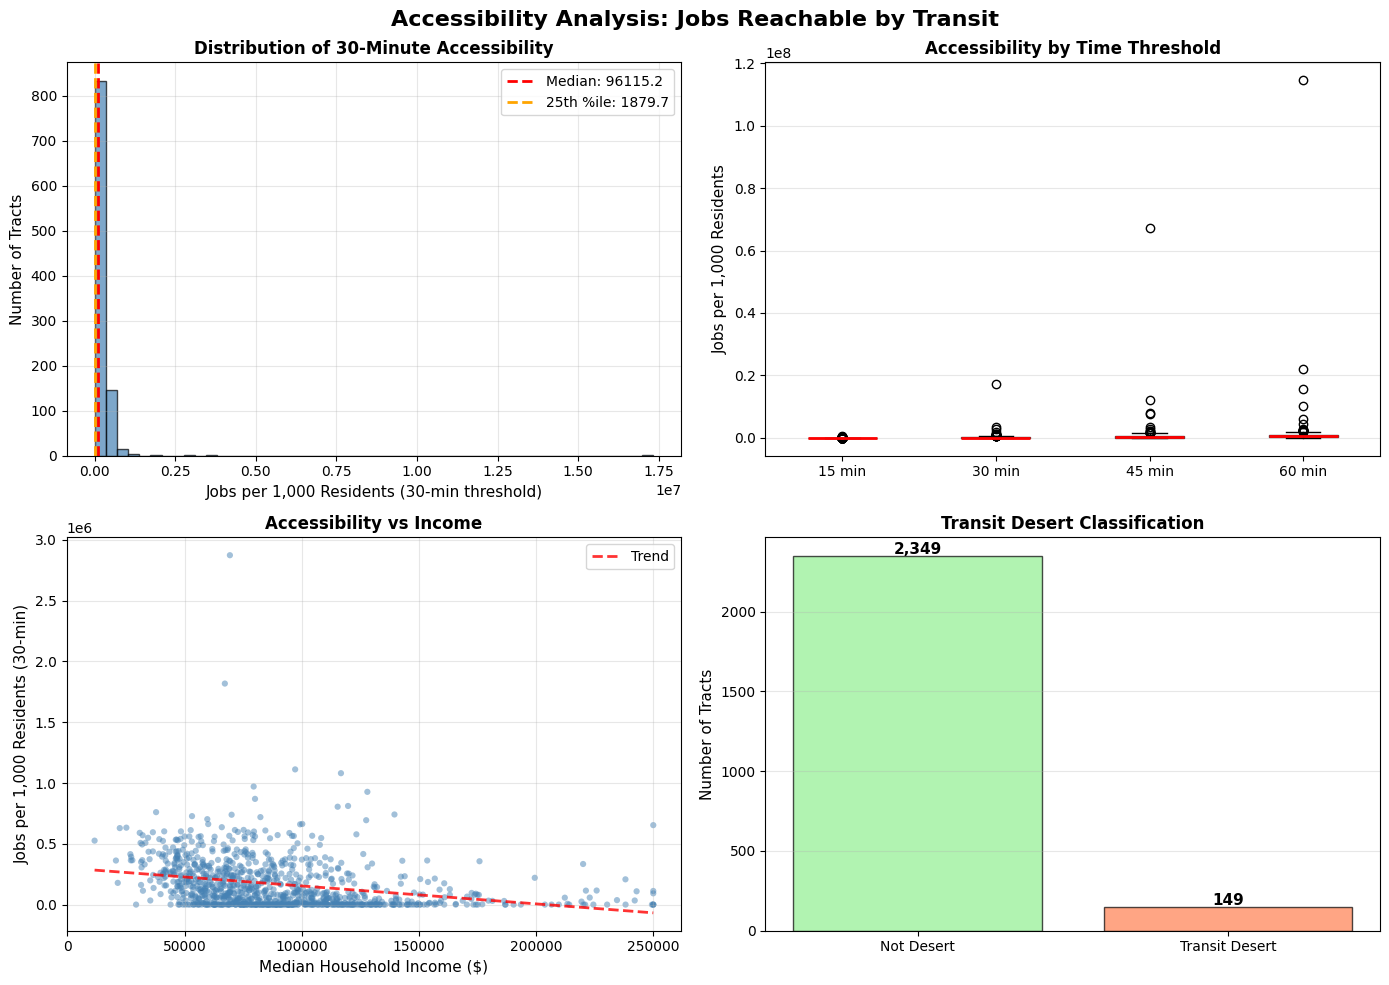

In [15]:
print("Creating accessibility distribution plots...")

if not isinstance(tracts_access, gpd.GeoDataFrame):
    tracts_access = tracts_access.merge(
        tracts[['GEOID', 'geometry']], 
        on='GEOID', 
        how='left'
    )
    tracts_access = gpd.GeoDataFrame(tracts_access, geometry='geometry', crs=tracts.crs)

print("Cleaning data for visualization...")
access_col_clean = f'{access_col}_capped' if f'{access_col}_capped' in tracts_access.columns else access_col

access_30_clean = tracts_access[access_col_clean].replace([np.inf, -np.inf], np.nan).dropna()
access_30_clean = access_30_clean[access_30_clean >= 0]  # Only non-negative

print(f"  Clean data points: {len(access_30_clean):,}")
print(f"  Min: {access_30_clean.min():.1f}, Max: {access_30_clean.max():.1f}")
print(f"  Mean: {access_30_clean.mean():.1f}, Median: {access_30_clean.median():.1f}")

median_access_clean = access_30_clean.median()
q25_access_clean = access_30_clean.quantile(0.25)
q75_access_clean = access_30_clean.quantile(0.75)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Accessibility Analysis: Jobs Reachable by Transit', fontsize=16, fontweight='bold')

axes[0, 0].hist(access_30_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(median_access_clean, color='red', linestyle='--', linewidth=2, label=f'Median: {median_access_clean:.1f}')
axes[0, 0].axvline(q25_access_clean, color='orange', linestyle='--', linewidth=2, label=f'25th %ile: {q25_access_clean:.1f}')
axes[0, 0].set_xlabel('Jobs per 1,000 Residents (30-min threshold)', fontsize=11)
axes[0, 0].set_ylabel('Number of Tracts', fontsize=11)
axes[0, 0].set_title('Distribution of 30-Minute Accessibility', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

threshold_data = []
for t in THRESHOLDS:
    col = f'access_{t}min_per1k_capped' if f'access_{t}min_per1k_capped' in tracts_access.columns else f'access_{t}min_per1k'
    clean_data = tracts_access[col].replace([np.inf, -np.inf], np.nan).dropna()
    clean_data = clean_data[clean_data >= 0]  # Only non-negative
    threshold_data.append(clean_data)

axes[0, 1].boxplot(threshold_data, labels=[f'{t} min' for t in THRESHOLDS], 
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Jobs per 1,000 Residents', fontsize=11)
axes[0, 1].set_title('Accessibility by Time Threshold', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

scatter_data = tracts_access[[access_col_clean, 'median_income']].copy()
scatter_data = scatter_data.replace([np.inf, -np.inf], np.nan).dropna()
scatter_data = scatter_data[(scatter_data[access_col_clean] >= 0) & 
                            (scatter_data['median_income'] > 0)]

axes[1, 0].scatter(scatter_data['median_income'], scatter_data[access_col_clean], 
                   alpha=0.5, s=20, c='steelblue', edgecolors='none')
axes[1, 0].set_xlabel('Median Household Income ($)', fontsize=11)
axes[1, 0].set_ylabel('Jobs per 1,000 Residents (30-min)', fontsize=11)
axes[1, 0].set_title('Accessibility vs Income', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

if len(scatter_data) > 2:
    try:
        z = np.polyfit(scatter_data['median_income'], scatter_data[access_col_clean], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(scatter_data['median_income'].min(), 
                             scatter_data['median_income'].max(), 100)
        axes[1, 0].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend')
        axes[1, 0].legend()
    except:
        pass  # Skip trend line if fit fails

desert_counts = tracts_access['transit_desert'].value_counts()
colors = ['lightgreen', 'coral']
axes[1, 1].bar(['Not Desert', 'Transit Desert'], 
               [desert_counts.get(False, 0), desert_counts.get(True, 0)],
               color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Number of Tracts', fontsize=11)
axes[1, 1].set_title('Transit Desert Classification', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')
for i, (label, count) in enumerate(zip(['Not Desert', 'Transit Desert'], 
                                        [desert_counts.get(False, 0), desert_counts.get(True, 0)])):
    axes[1, 1].text(i, count + 10, f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plot_path = outputs / "accessibility_analysis.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved accessibility analysis plots to {plot_path.relative_to(ROOT)}")
plt.show()


Creating accessibility choropleth map...
✓ Saved accessibility map to outputs/map_accessibility_30min.png


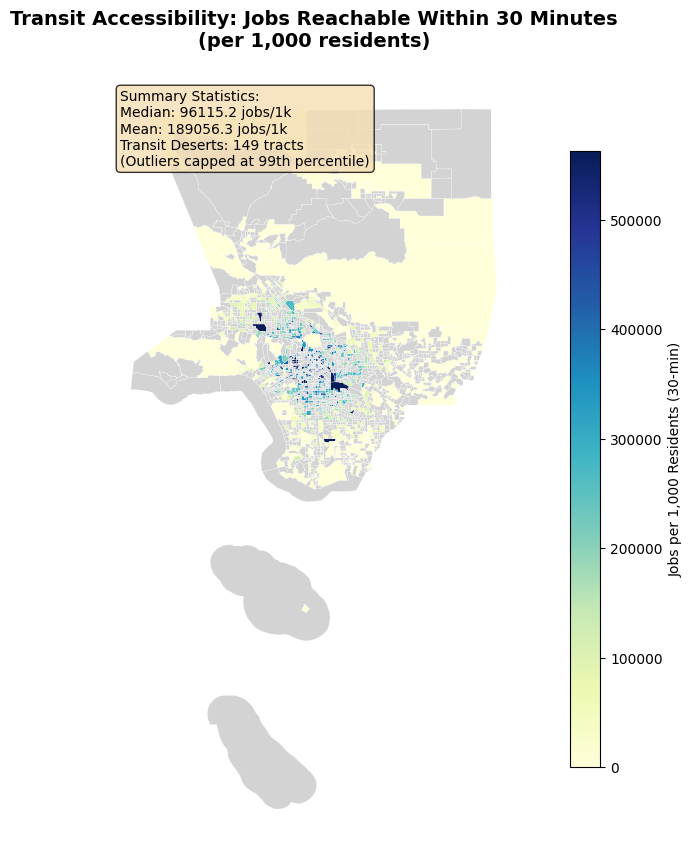

In [16]:
print("Creating accessibility choropleth map...")

if not isinstance(tracts_access, gpd.GeoDataFrame):
    tracts_access = tracts_access.merge(
        tracts[['GEOID', 'geometry']], 
        on='GEOID', 
        how='left'
    )
    tracts_access = gpd.GeoDataFrame(tracts_access, geometry='geometry', crs=tracts.crs)

# Use capped column for mapping (avoids infinite values)
map_col = f'{access_col}_capped' if f'{access_col}_capped' in tracts_access.columns else access_col

tracts_access[map_col] = tracts_access[map_col].replace([np.inf, -np.inf], np.nan)

map_data_clean = tracts_access[map_col].dropna()
median_map = map_data_clean.median() if len(map_data_clean) > 0 else 0
mean_map = map_data_clean.mean() if len(map_data_clean) > 0 else 0

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
tracts_access.plot(column=map_col,
                   cmap='YlGnBu',
                   legend=True,
                   ax=ax,
                   missing_kwds={'color': 'lightgrey', 'label': 'No data'},
                   edgecolor='white',
                   linewidth=0.2,
                   legend_kwds={'label': 'Jobs per 1,000 Residents (30-min)', 'shrink': 0.8},
                   vmin=0,  # Set explicit range to avoid infinite issues
                   vmax=map_data_clean.quantile(0.95) if len(map_data_clean) > 0 else 1000)
ax.set_title('Transit Accessibility: Jobs Reachable Within 30 Minutes\n(per 1,000 residents)', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

stats_text = f'''Summary Statistics:
Median: {median_map:.1f} jobs/1k
Mean: {mean_map:.1f} jobs/1k
Transit Deserts: {n_deserts:,} tracts
(Outliers capped at 99th percentile)'''
ax.text(0.02, 0.98, stats_text,
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

map_path = outputs / "map_accessibility_30min.png"
plt.savefig(map_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved accessibility map to {map_path.relative_to(ROOT)}")
plt.show()


Creating transit desert identification map...
✓ Saved transit desert map to outputs/map_transit_deserts.png


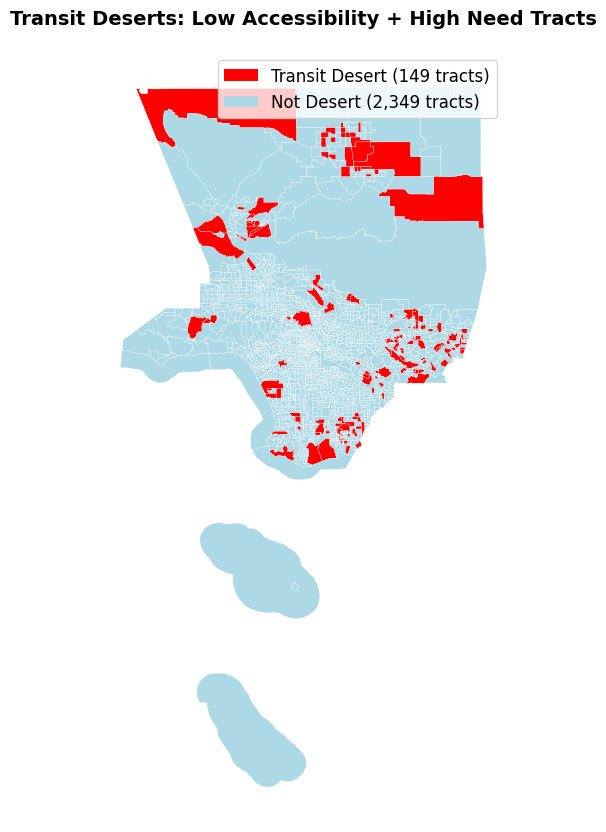

In [17]:
print("Creating transit desert identification map...")

if not isinstance(tracts_access, gpd.GeoDataFrame):
    tracts_access = tracts_access.merge(
        tracts[['GEOID', 'geometry']], 
        on='GEOID', 
        how='left'
    )
    tracts_access = gpd.GeoDataFrame(tracts_access, geometry='geometry', crs=tracts.crs)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

tracts_access['desert_color'] = tracts_access['transit_desert'].map({
    True: 'red',
    False: 'lightblue'
})

tracts_access.plot(color=tracts_access['desert_color'],
                   edgecolor='white',
                   linewidth=0.2,
                   ax=ax,
                   legend=False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label=f'Transit Desert ({n_deserts:,} tracts)'),
    Patch(facecolor='lightblue', label=f'Not Desert ({len(tracts_access) - n_deserts:,} tracts)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

ax.set_title('Transit Deserts: Low Accessibility + High Need Tracts', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

desert_map_path = outputs / "map_transit_deserts.png"
plt.savefig(desert_map_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved transit desert map to {desert_map_path.relative_to(ROOT)}")
plt.show()


In [18]:
print("Creating interactive map...")

if not isinstance(tracts_access, gpd.GeoDataFrame):
    tracts_access = tracts_access.merge(
        tracts[['GEOID', 'geometry']], 
        on='GEOID', 
        how='left'
    )
    tracts_access = gpd.GeoDataFrame(tracts_access, geometry='geometry', crs=tracts.crs)

la_center = [34.05, -118.25]
m = folium.Map(location=la_center, zoom_start=10, tiles='CartoDB positron')

# Use capped column for interactive map (avoids infinite values)
map_col_interactive = f'{access_col}_capped' if f'{access_col}_capped' in tracts_access.columns else access_col
tracts_access[map_col_interactive] = tracts_access[map_col_interactive].replace([np.inf, -np.inf], np.nan)

folium.Choropleth(
    geo_data=tracts_access.to_json(),
    data=tracts_access,
    columns=['GEOID', map_col_interactive],
    key_on='feature.properties.GEOID',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Jobs per 1,000 Residents (30-min)',
    nan_fill_color='lightgrey'
).add_to(m)

deserts_gdf = tracts_access[tracts_access['transit_desert']].copy()
for idx, row in deserts_gdf.iterrows():
    # Access geometry from Series (iterrows returns Series)
    geom = row['geometry']
    if geom is not None:
        folium.GeoJson(
            geom.__geo_interface__,
            style_function=lambda x: {
                'fillColor': 'red',
                'color': 'red',
                'weight': 2,
                'fillOpacity': 0.3
            },
            tooltip=f"GEOID: {row['GEOID']}<br>"
                    f"Accessibility: {row[access_col]:.1f} jobs/1k<br>"
                    f"Population: {row['pop_total']:,.0f}<br>"
                    f"Income: ${row['median_income']:,.0f}"
        ).add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 250px; height: 150px; 
            background-color: white; z-index:9999; font-size:14px; padding: 10px;
            border:2px solid grey; border-radius: 5px">
<p><b>Legend</b></p>
<p>Color scale: Jobs per 1,000 residents (30-min)</p>
<p><span style="color:red">Red outline</span>: Transit Deserts</p>
<p>Click tracts for details</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

interactive_map_path = outputs / "map_accessibility_interactive.html"
m.save(str(interactive_map_path))
print(f"✓ Saved interactive map to {interactive_map_path.relative_to(ROOT)}")
print("  Open in browser to explore!")


Creating interactive map...
✓ Saved interactive map to outputs/map_accessibility_interactive.html
  Open in browser to explore!


## Summary

**What we calculated:**
- Jobs reachable within 15/30/45/60 minutes for each origin tract
- Per-capita accessibility (jobs per 1,000 residents)
- Transit desert identification (low access + high need)

**Key Findings:**
- [Review the statistics printed above]

**Next Steps (Notebook 04):**
- Spatial analysis (Moran's I, spatial clustering)
- Spatial regression models
- Deeper exploration of transit desert characteristics
